<a href="https://colab.research.google.com/github/jadstronaute/Projet_GPI_JE/blob/main/GPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet de gestion de projet indormatique

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tifffile as tif
from scipy import ndimage

from PIL import Image
import importlib.util
import subprocess
import sys
import requests
from io import BytesIO  # Ensure this import is present

from skimage import io, transform
from scipy.signal import correlate2d

import urllib.request
#import io
#%pip install Bio
from Bio.PDB import PDBParser, PDBIO
from mpl_toolkits.mplot3d import Axes3D


# Ensure scikit-image is available for bilateral denoising.
if importlib.util.find_spec('skimage') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-image'])

from skimage.restoration import denoise_bilateral


# Install required package (run once)
#%pip install mrcfile

import mrcfile

# %pip install gdown

import gdown
import mrcfile
import os

# if needed, you can install packages using pip
# %pip install scikit-image

# Set random seed for reproducibility
np.random.seed(42)

print("yippeeeee")

yippeeeee


Now to import the mrc files from google drive, if you wanna import something else just change the ID

Downloading...
From (original): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr
From (redirected): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr&confirm=t&uuid=0ca15b1c-e6b6-46a3-b46a-f0e1326b594e
To: /content/map.mrc
100%|██████████| 228M/228M [00:01<00:00, 118MB/s]



File size: 217.27 MB
First 4 bytes: b'\xfc\x1c\x00\x00'
✓ File appears valid

Loading MRC file...
✓ MRC loaded successfully

MRC DATA INFO
Shape: (7676, 7420)
Dtype: float32
Min/Max: -3.31172 41.723225

Detected: single 2D image


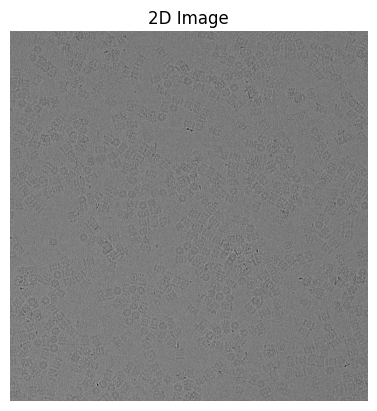

In [7]:
file_id = "1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr"
output = "map.mrc"

print("Downloading MRC file...")
gdown.download(id=file_id, output=output, quiet=False)


file_size = os.path.getsize(output)
print(f"\nFile size: {file_size / (1024**2):.2f} MB")

with open(output, "rb") as f:
    header = f.read(4)

print("First 4 bytes:", header)

if header.startswith(b"<"):
    raise ValueError("❌ Downloaded file is HTML, not MRC. Check sharing permissions.")

if file_size < 10000:
    raise ValueError("❌ File too small — likely incorrect download.")

print("✓ File appears valid")

print("\nLoading MRC file...")

with mrcfile.open(output, permissive=True) as mrc:
    if mrc.data is None:
        raise ValueError("❌ MRC file contains no readable data")
    data = mrc.data.copy()

print("✓ MRC loaded successfully")

print("\n" + "="*60)
print("MRC DATA INFO")
print("="*60)
print("Shape:", data.shape)
print("Dtype:", data.dtype)
print("Min/Max:", data.min(), data.max())


if data.ndim == 3:
    print("\nDetected: 3D volume")

    z, y, x = np.array(data.shape) // 2

    # ------------------------------------------
    # CENTRAL SLICES (RAW)
    # ------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    slices = [
        (data[z, :, :], "XY slice"),
        (data[:, y, :], "XZ slice"),
        (data[:, :, x], "YZ slice"),
    ]

    for ax, (img, title) in zip(axes, slices):
        vmin = np.percentile(img, 5)
        vmax = np.percentile(img, 95)
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("\nGenerating summed projections...")

    proj_xy = np.sum(data, axis=0)
    proj_xz = np.sum(data, axis=1)
    proj_yz = np.sum(data, axis=2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    projections = [
        (proj_xy, "XY Projection (sum Z)"),
        (proj_xz, "XZ Projection (sum Y)"),
        (proj_yz, "YZ Projection (sum X)")
    ]

    for ax, (proj, title) in zip(axes, projections):
        vmin = np.percentile(proj, 5)
        vmax = np.percentile(proj, 95)
        ax.imshow(proj, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

elif data.ndim == 2:
    print("\nDetected: single 2D image")

    vmin = np.percentile(data, 5)
    vmax = np.percentile(data, 95)

    plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title("2D Image")
    plt.axis('off')
    plt.show()

else:
    print("\n⚠️ Unrecognized format")

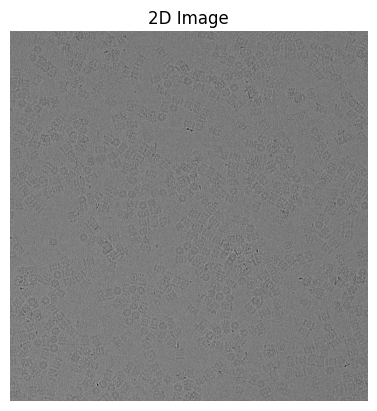

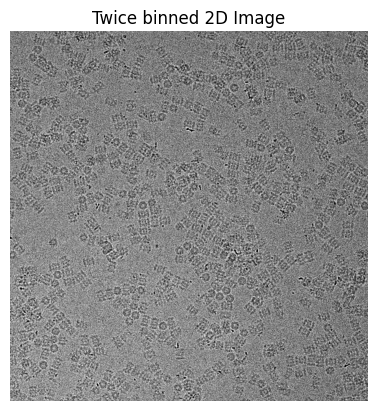

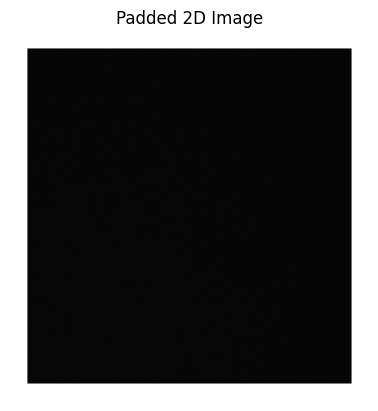

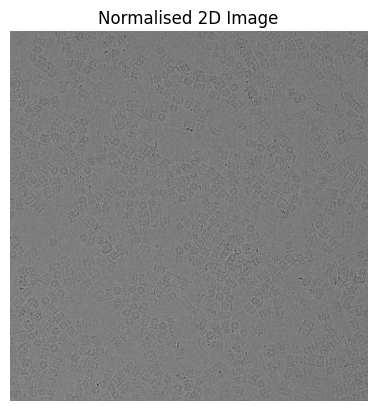

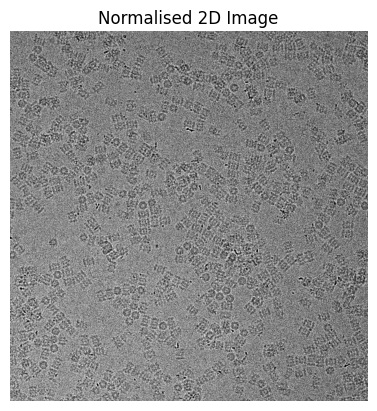

In [21]:
data
plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("2D Image")
plt.axis('off')
plt.show()

def bin_image(image, bin_size):
    """
    Performs binning (spatial downsampling) on an image.

    Args:
        image: Input image as numpy array
        bin_size: Size of the bin (e.g., 2 for 2x2 binning)

    Returns:
        Binned image with reduced resolution
    """
    h, w = image.shape
    # Calculate new dimensions
    new_h = h // bin_size
    new_w = w // bin_size

    # Reshape and compute mean of each bin
    binned = image[:new_h*bin_size, :new_w*bin_size].reshape(new_h, bin_size, new_w, bin_size)
    binned = binned.mean(axis=(1, 3)).astype(np.uint8)

    return binned

binned_data = bin_image(data, 4)
plt.imshow(bin_image(data, 4), cmap='gray', vmin=np.percentile(binned_data, 5), vmax=np.percentile(binned_data, 95))
plt.title("Twice binned 2D Image")
plt.axis('off')
plt.show()

def apply_padding(img, pad_width, mode='constant', constant_value=255):
    """
    Apply padding to an image using NumPy.

    Parameters:
    -----------
    img : ndarray
        Input image
    pad_width : int or tuple
        Number of pixels to pad on each side
    mode : str
        Padding mode: 'constant', 'edge', 'reflect', 'wrap'
    constant_value : int
        Value used for constant padding

    Returns:
    --------
    padded : ndarray
        Padded image
    """
    if isinstance(pad_width, int):
        pad_width = ((pad_width, pad_width), (pad_width, pad_width))

    if mode == 'constant':
        padded = np.pad(img, pad_width, mode='constant', constant_values=constant_value)
    else:
        padded = np.pad(img, pad_width, mode=mode)

    return padded

padded_data = apply_padding(data, 400)
plt.imshow(padded_data, cmap='gray', vmin=np.percentile(padded_data, 5), vmax=np.percentile(padded_data, 95))
plt.title("Padded 2D Image")
plt.axis('off')
plt.show()


normalised_data = data / data.max()
plt.imshow(normalised_data, cmap='gray', vmin=np.percentile(normalised_data, 5), vmax=np.percentile(normalised_data, 95))
plt.title("Normalised 2D Image")
plt.axis('off')
plt.show()

normalised_binned_data = binned_data / binned_data.max()
plt.imshow(normalised_binned_data, cmap='gray', vmin=np.percentile(normalised_binned_data, 5), vmax=np.percentile(normalised_binned_data, 95))
plt.title("Normalised 2D Image")
plt.axis('off')
plt.show()
